<a href="https://colab.research.google.com/github/nbontiff/ITAI-1371-ML-Labs/blob/main/L04_NigelBontiff_ITAI1371.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Module 04 Lab - Exploratory Data Analysis

What is Exploratory Data Analysis (EDA)?

This 4 part lab will explore
1) EDA - the process of using summary statistics and visualizations to understand a dataset's main characteristics.
2) Descriptive Statistics.
3) Visual EDA - turning data into insights.
4) Student Experimentation.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset directly from a URL
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

print("--- First 5 Rows ---")
print(df.head())

print("--- Basic Info ---")

# .info() is a great first command.
# It tells us the column names, how many non-null values are in each column,
# and their data types.
# Notice that 'Age' and 'Cabin' have missing values!
df.info()

--- First 5 Rows ---
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.050

In [4]:
# Get summary statistics for numerical columns

print("--- Descriptive Statistics ---")
print(df.describe())

print("--- Key Insights from Statistics ---")
print(f"The average age of a passenger was {df['Age'].mean():.1f} years.")
print(f"The overall survival rate was {df['Survived'].mean():.1%}.")
print(f"Fares ranged from ${df['Fare'].min():.2f} to a whopping ${df['Fare'].max():.2f}.")

--- Descriptive Statistics ---
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  
--- Key Insights from Statistics ---
The average a

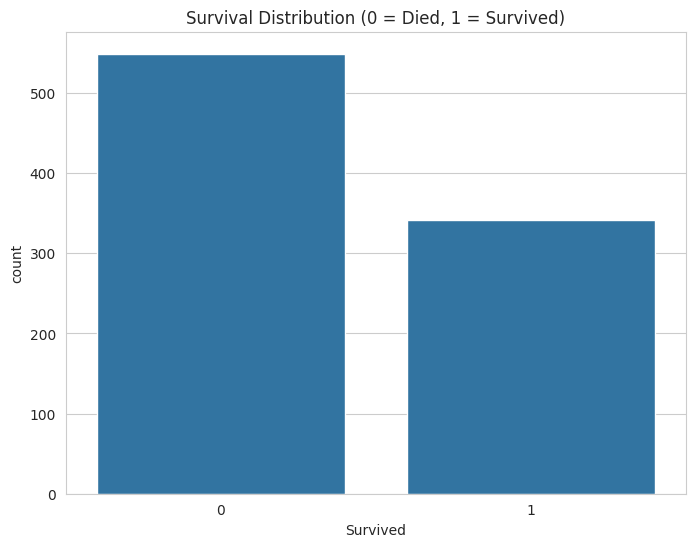

Insight: Far more people died than survived. This is an example of an imbalanced dataset, which can sometimes be a challenge for machine learning models.


In [5]:
sns.set_style('whitegrid')  # Sets a nice visual style for our plots

plt.figure(figsize=(8, 6))

sns.countplot(x='Survived', data=df)

plt.title('Survival Distribution (0 = Died, 1 = Survived)')

plt.show()

print("Insight: Far more people died than survived. This is an example of an imbalanced dataset, which can sometimes be a challenge for machine learning models.")

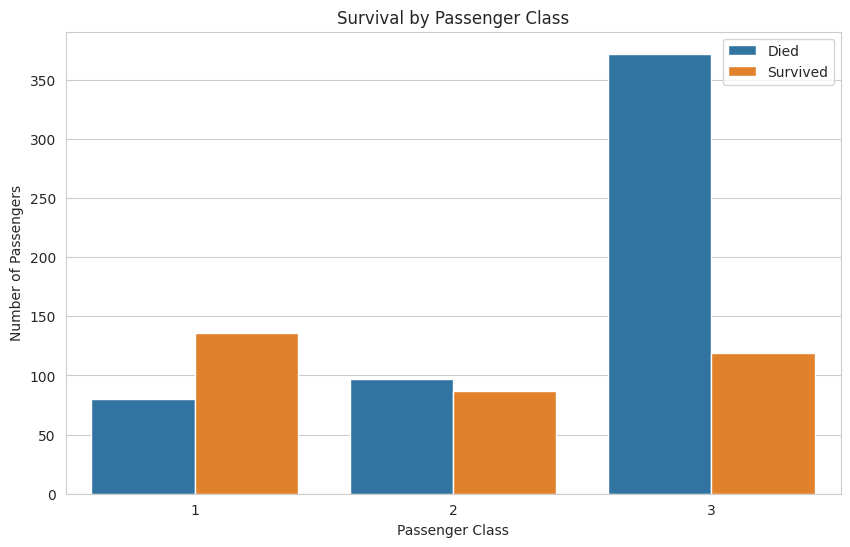

Insight: This is a very strong pattern. 1st class passengers had a much higher chance of survival compared to 3rd class passengers. Passenger class seems to have made a difference in survival outcomes.


In [6]:
plt.figure(figsize=(10, 6))

sns.countplot(x='Pclass', hue='Survived', data=df)

plt.title('Survival by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Number of Passengers')

plt.legend(['Died', 'Survived'])

plt.show()

print("Insight: This is a very strong pattern. 1st class passengers had a much higher chance of survival compared to 3rd class passengers. Passenger class seems to have made a difference in survival outcomes.")

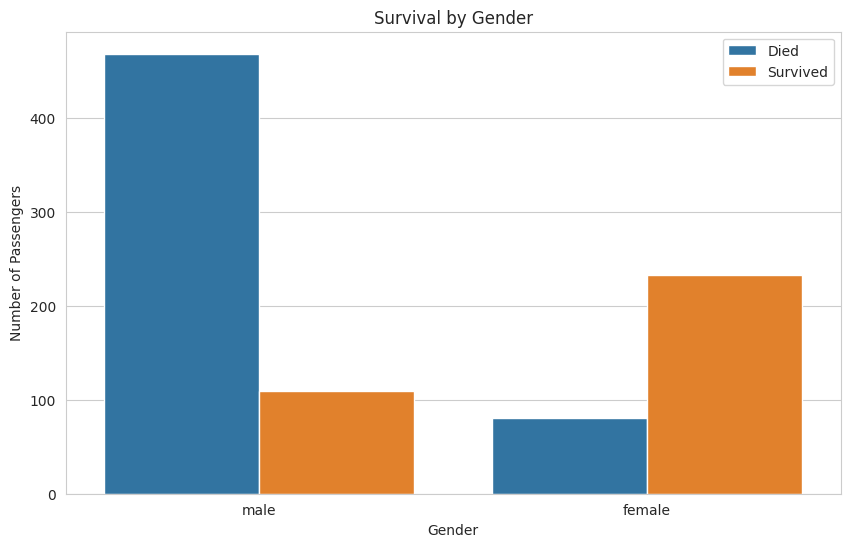

Insight: The pattern is very clear. A much higher proportion of females survived compared to males. This suggests that gender was a strong predictor of survival in this dataset.


In [7]:
plt.figure(figsize=(10, 6))

sns.countplot(x='Sex', hue='Survived', data=df)

plt.title('Survival by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Passengers')

plt.legend(['Died', 'Survived'])

plt.show()

print("Insight: The pattern is very clear. A much higher proportion of females survived compared to males. This suggests that gender was a strong predictor of survival in this dataset.")

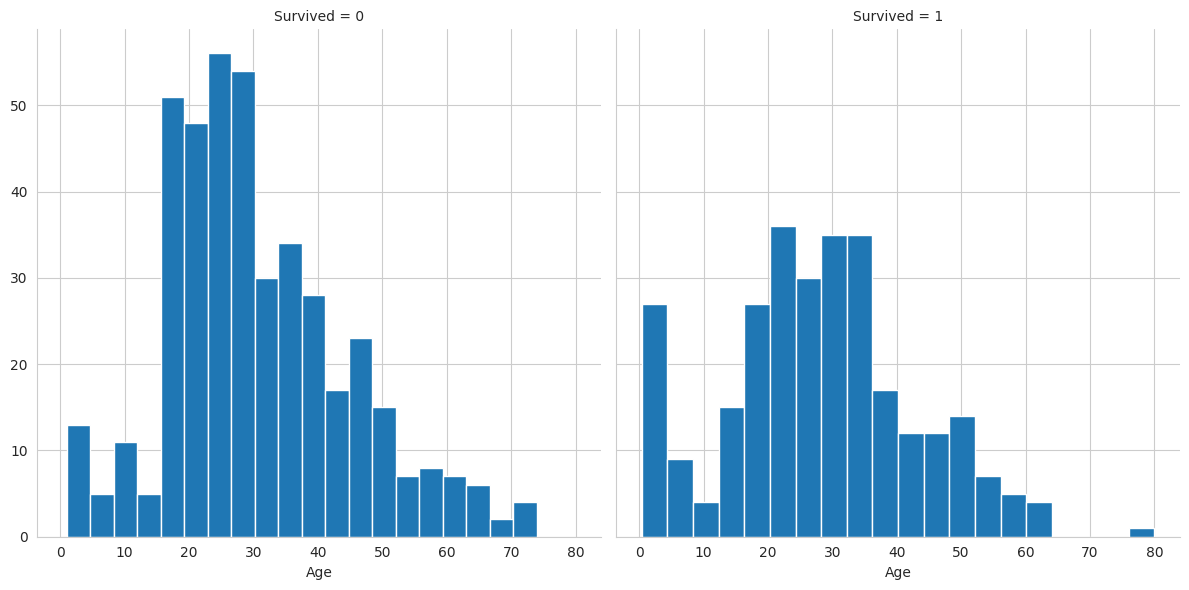

Insight: The age distribution for passengers who did not survive appears mostly concentrated around the 20-40 age range. For passengers who survived, there is a noticeable group of young children. This supports the idea that age may have played a role in survival outcomes.


In [8]:
# A FacetGrid allows us to create multiple plots side-by-side to compare distributions.
# Here, we create one histogram for passengers who died and one for passengers who survived.

g = sns.FacetGrid(df, col='Survived', height=6)

g.map(plt.hist, 'Age', bins=20)

plt.show()

print("Insight: The age distribution for passengers who did not survive appears mostly concentrated around the 20-40 age range. For passengers who survived, there is a noticeable group of young children. This supports the idea that age may have played a role in survival outcomes.")

Experiment 1: Port of Embarkation

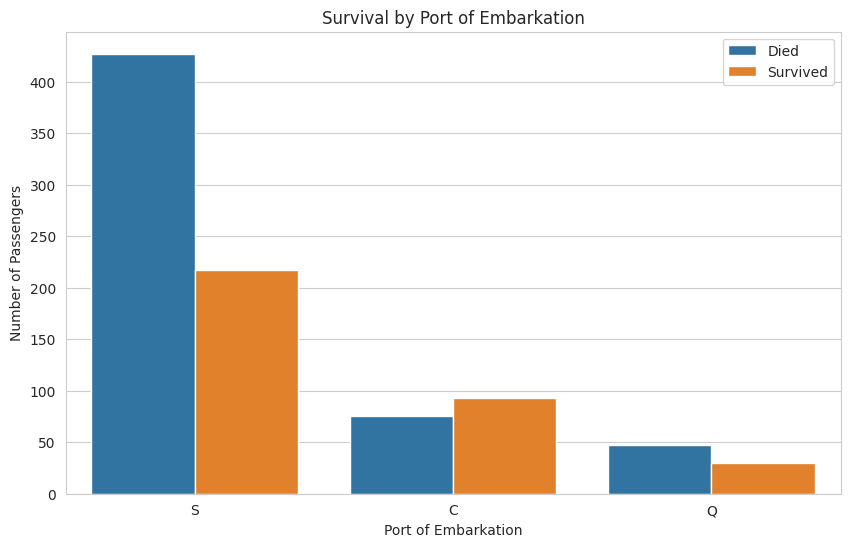

Survival rate by port of embarkation:
Embarked
C    55.4
Q    39.0
S    33.7
Name: Survived, dtype: float64


In [9]:
# Experiment 1: Survival by Port of Embarkation

plt.figure(figsize=(10, 6))

sns.countplot(x='Embarked', hue='Survived', data=df)

plt.title('Survival by Port of Embarkation')
plt.xlabel('Port of Embarkation')
plt.ylabel('Number of Passengers')
plt.legend(['Died', 'Survived'])

plt.show()

# Survival rate
embarked_survival = df.groupby('Embarked')['Survived'].mean()

print("Survival rate by port of embarkation:")
print((embarked_survival * 100).round(1))

Experiment 2: Fare vs. Survival

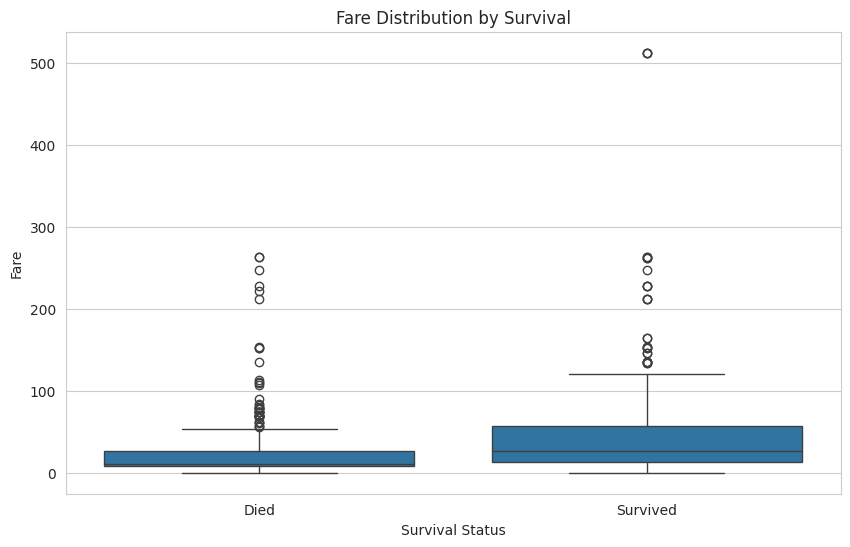

Fare summary by survival status:
          count       mean        std  min      25%   50%   75%       max
Survived                                                                 
0         549.0  22.117887  31.388207  0.0   7.8542  10.5  26.0  263.0000
1         342.0  48.395408  66.596998  0.0  12.4750  26.0  57.0  512.3292


In [10]:
# Experiment 2: Fare vs. Survival

plt.figure(figsize=(10, 6))

sns.boxplot(x='Survived', y='Fare', data=df)

plt.title('Fare Distribution by Survival')
plt.xlabel('Survival Status')
plt.ylabel('Fare')
plt.xticks([0, 1], ['Died', 'Survived'])

plt.show()

# Statistics comparison for passengers who died vs. survived
fare_summary = df.groupby('Survived')['Fare'].describe()

print("Fare summary by survival status:")
print(fare_summary)

# Knowledge Check

1) What is the primary goal of Exploratory Data Analysis (EDA)?
    - To understand the dataset before building a model. It helps us find patterns, missing values, outliers, and relationships in the data.

2) Based on the plots in this lab, what kind of person had the best chance of surviving the Titanic?
    - Based on the plots, a young female passenger in 1st class seemed to have the best chance of surviving.

3) Why is it important to visualize data instead of just looking at summary statistics? What can a plot show you that a number like 'mean' or 'count' can't?
    - Visualizing data is important because plots can show patterns, outliers, and group differences that summary statistics can hide. A mean or count gives one number, but a graph shows the bigger picture.